# Helical Field Polarization Distribution Mach Test

### Literally same as torodial but now alpha > 0

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def helical_field_depol_test(M_A, alpha, iaxis, g_size=64, plotting=False):

    # =========================
    # PARAMETERS
    # =========================
    I0 = 1.0
    corr_r = 0.9   # LOS correlation coefficient
    turb_sigma = M_A

    # =========================
    # GRID
    # =========================
    x = np.linspace(-1, 1, g_size)
    y = np.linspace(-1, 1, g_size)
    z = np.linspace(-1, 1, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    # avoid singularity at r=0
    r = np.sqrt(X**2 + Y**2) + 1e-8

    # base toroidal field (unrotated in z)
    Bx0 = (-Y * np.cos(alpha)) / r
    By0 = ( X * np.cos(alpha)) / r
    Bz0 = np.full_like(X, np.sin(alpha))

    # =========================
    # Turbulence
    # =========================
    delta_theta = np.zeros((g_size, g_size, g_size))
    axes = [0, 1, 2]
    axes.remove(iaxis)
    i1, i2 = axes

    for i in range(g_size):
        for j in range(g_size):
            val = np.random.normal(scale=turb_sigma)
            for k in range(g_size):
                idx = [0, 0, 0]
                idx[iaxis] = k
                idx[i1] = i
                idx[i2] = j
                delta_theta[tuple(idx)] = val
                val = corr_r * val + np.random.normal(scale=turb_sigma * np.sqrt(1 - corr_r**2))

    # =========================
    # APPLY TURBULENT ROTATION
    # =========================
    if iaxis == 0:   # LOS = x
        By_new = By0*np.cos(delta_theta) - Bz0*np.sin(delta_theta)
        Bz_new = By0*np.sin(delta_theta) + Bz0*np.cos(delta_theta)
        Bx_new = Bx0
    elif iaxis == 1: # LOS = y
        Bx_new = Bx0*np.cos(delta_theta) - Bz0*np.sin(delta_theta)
        Bz_new = Bx0*np.sin(delta_theta) + Bz0*np.cos(delta_theta)
        By_new = By0
    else:            # LOS = z
        Bx_new = Bx0*np.cos(delta_theta) - By0*np.sin(delta_theta)
        By_new = Bx0*np.sin(delta_theta) + By0*np.cos(delta_theta)
        Bz_new = Bz0

    Bx, By, Bz = Bx_new, By_new, Bz_new


    # =========================
    # Calculate Stokes for appropriate POS components
    # =========================
    # Define LOS and POS components
    if iaxis == 0:        # LOS = x → POS = (y,z)
        B_los = Bx
        B1, B2 = By, Bz

    elif iaxis == 1:      # LOS = y → POS = (x,z)
        B_los = By
        B1, B2 = Bx, Bz

    else:                 # LOS = z → POS = (x,y)
        B_los = Bz
        B1, B2 = Bx, By

    B_los2  = B_los**2
    B_perp2 = B1**2 + B2**2
    Btot2   = B_perp2 + B_los2

    # Geometrical depolarization
    cos2g = B_perp2 / (Btot2 + 1e-12)
    I_local = I0 * np.ones_like(Btot2)

    # Safe division mask
    mask = B_perp2 > 1e-12

    Q = np.zeros_like(B1)
    U = np.zeros_like(B1)

    Q[mask] =  cos2g[mask] * (B2[mask]**2 - B1[mask]**2) / B_perp2[mask] #I_local[mask] *
    U[mask] =  cos2g[mask] * (2 * B1[mask] * B2[mask]) / B_perp2[mask]

    # LOS integration
    I_obs = I_local.sum(axis=iaxis)
    Q_obs = Q.sum(axis=iaxis)
    U_obs = U.sum(axis=iaxis)

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / (I_obs + 1e-12)
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)

    # plotting
    if plotting:

        skip = g_size // 10

        # 3D visualization
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.quiver(
            X[::skip, ::skip, ::skip],
            Y[::skip, ::skip, ::skip],
            Z[::skip, ::skip, ::skip],
            Bx[::skip, ::skip, ::skip],
            By[::skip, ::skip, ::skip],
            Bz[::skip, ::skip, ::skip],
            length=0.25, normalize=True,linewidth=1.5, arrow_length_ratio=0)
        ax.set_title("3D Helical")
        plt.show()

        mid = g_size // 2

        fig, axes = plt.subplots(1,3,figsize=(12,4))

        # LOS = x → POS = (y,z)
        axes[0].quiver(
            Y[mid, :, :],
            Z[mid, :, :],
            By[mid, :, :],
            Bz[mid, :, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[0].set_xlabel("Y")
        axes[0].set_ylabel("Z")
        axes[0].set_title("LOS X")

        # LOS = y → POS = (x,z)
        axes[1].quiver(
            X[:, mid, :],
            Z[:, mid, :],
            Bx[:, mid, :],
            Bz[:, mid, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Z")
        axes[1].set_title("LOS Y")

        # LOS = z → POS = (x,y)
        axes[2].quiver(
            X[:, :, mid],
            Y[:, :, mid],
            Bx[:, :, mid],
            By[:, :, mid],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[2].set_xlabel("X")
        axes[2].set_ylabel("Y")
        axes[2].set_title("LOS Z")

        plt.tight_layout()
        plt.show()

    return P_obs, phi_obs, cos2g.mean(axis=iaxis)


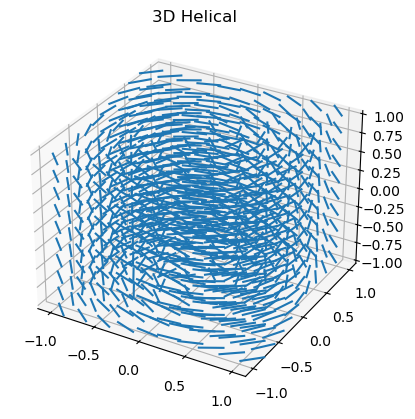

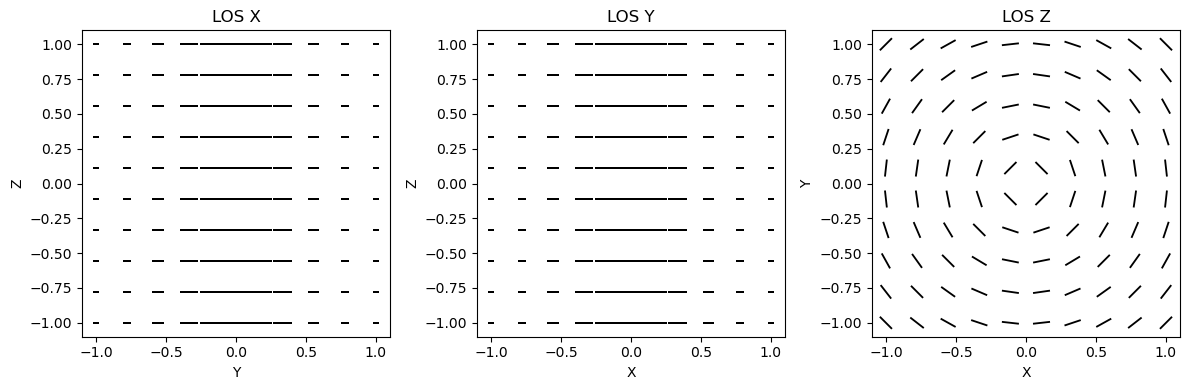

In [123]:
P,PHI,COS = helical_field_depol_test(M_A=0, alpha=0, iaxis=1, g_size=10, plotting=True)


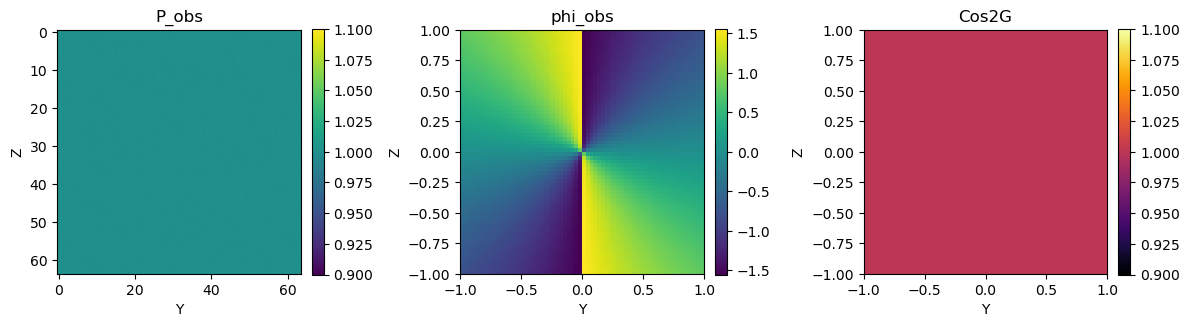

In [126]:
gsize = 64
P,PHI,COS = helical_field_depol_test(M_A=0, alpha=0, iaxis=2, g_size=gsize, plotting=False)

fig, axs = plt.subplots(1,3,figsize=(12,4))
extent = [-1, 1, -1, 1]

im0 = axs[0].imshow(P.T, cmap='viridis')
axs[0].set_xlabel("Y")
axs[0].set_ylabel("Z")
axs[0].set_title('P_obs')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(PHI.T,  origin='lower', extent=extent, cmap='viridis')
axs[1].set_xlabel("Y")
axs[1].set_ylabel("Z")
axs[1].set_title('phi_obs')
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(COS.T, origin='lower', extent=extent, cmap='inferno')
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_title('Cos2G')
plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)


# gsize = 64
# P,PHI,COS = helical_field_depol_test(M_A=0, alpha=0, iaxis=0, g_size=gsize, plotting=False)

# fig, axs = plt.subplots(1,3,figsize=(12,4))

# im0 = axs[0].imshow(P, cmap='viridis')
# plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
# axs[0].set_title('P_obs')
# axs[0].set_ylim(0,gsize)

# im1 = axs[1].imshow(PHI, cmap='viridis')
# plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
# axs[1].set_title('phi_obs')
# axs[1].set_ylim(0,gsize)

# im2 = axs[2].imshow(COS, cmap='inferno')
# plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
# axs[2].set_title('Cos2G')
# axs[2].set_ylim(0,gsize)

plt.tight_layout()

In [117]:
# P,PHI,COS = helical_field_depol_test(M_A=0, alpha=0, iaxis=2, g_size=64, plotting=False)

# print("Mean P_obs:", P.mean())
# print('Max P_obs:', P.max())
# print(np.median(P))
# plt.plot(P.flatten(), '.', alpha=0.5)
# plt.show()
# plt.hist(P.flatten(), bins=10, density=True, alpha=0.4)

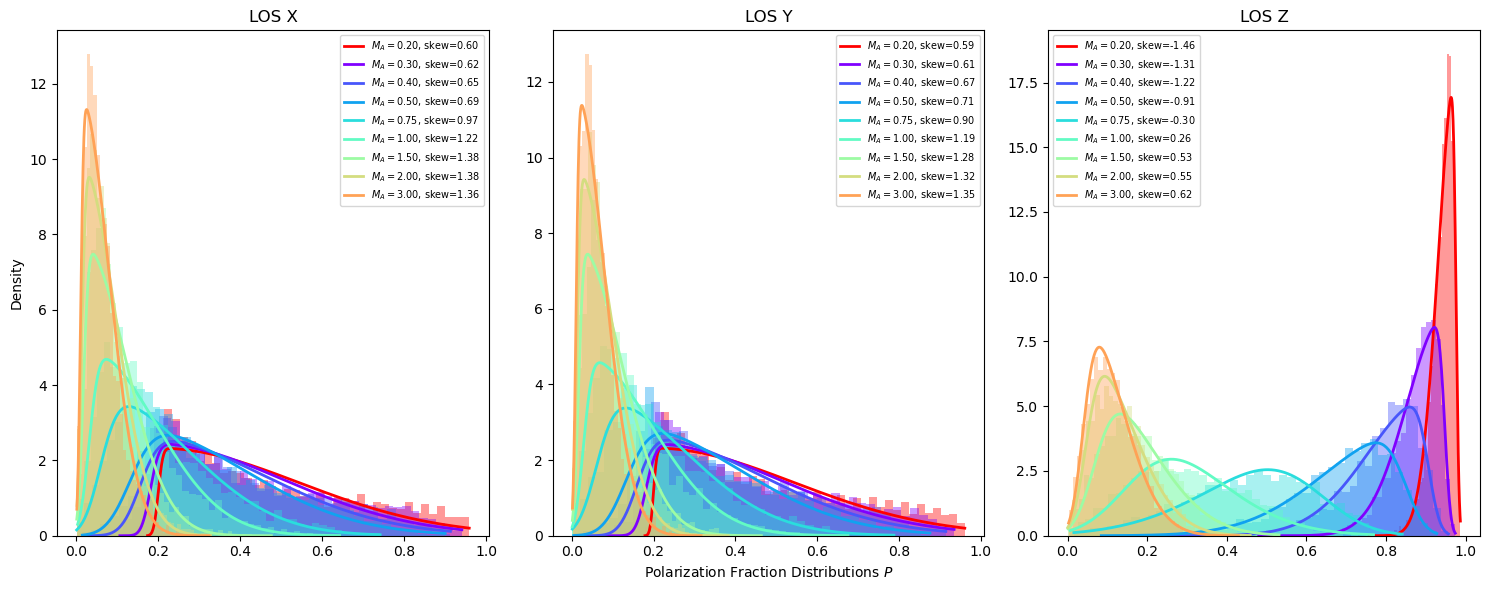

In [127]:
from scipy.stats import skew, skewnorm
# mach_vals = [0,0.01,0.02,0.05]
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3]
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

fig, axes = plt.subplots(1,3,figsize=(15,6))

for nax in range(3):
    for imach in mach_vals:

        # simulate
        gsize = 64
        P,PHI,COS = helical_field_depol_test(M_A=imach, alpha=0, iaxis=nax, g_size=gsize, plotting=False)

        # flatten & clip to >0
        Pflat = P.flatten()
        Pflat = Pflat[Pflat > 0]

        # --- compute raw skewness ---
        skew_val = skew(Pflat, bias=False)

        # --- fit skewnormal distribution ---
        # skewnorm.fit returns (a, loc, scale)
        a, loc, scale = skewnorm.fit(Pflat)

        # build PDF for plotting
        x = np.linspace(Pflat.min(), Pflat.max(), 300)
        pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

        # --- histogram ---
        axes[nax].hist(Pflat, bins=40, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # --- overlay skewnormal fit ---
        axes[nax].plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color=color[mach_vals.index(imach)-1])

    axes[nax].legend(fontsize=7)

axes[1].set_xlabel("Polarization Fraction Distributions $P$")
axes[0].set_ylabel("Density")
axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')
# axes[0].yscale("log")
# axes[0].set_ylim(0,2000)
# axes[1].set_ylim(0,6000)
# axes[2].set_ylim(0,1e4)
# plt.title('Uniform Field: Polarization Distributions for Varying Mach #')
plt.tight_layout()
plt.show()


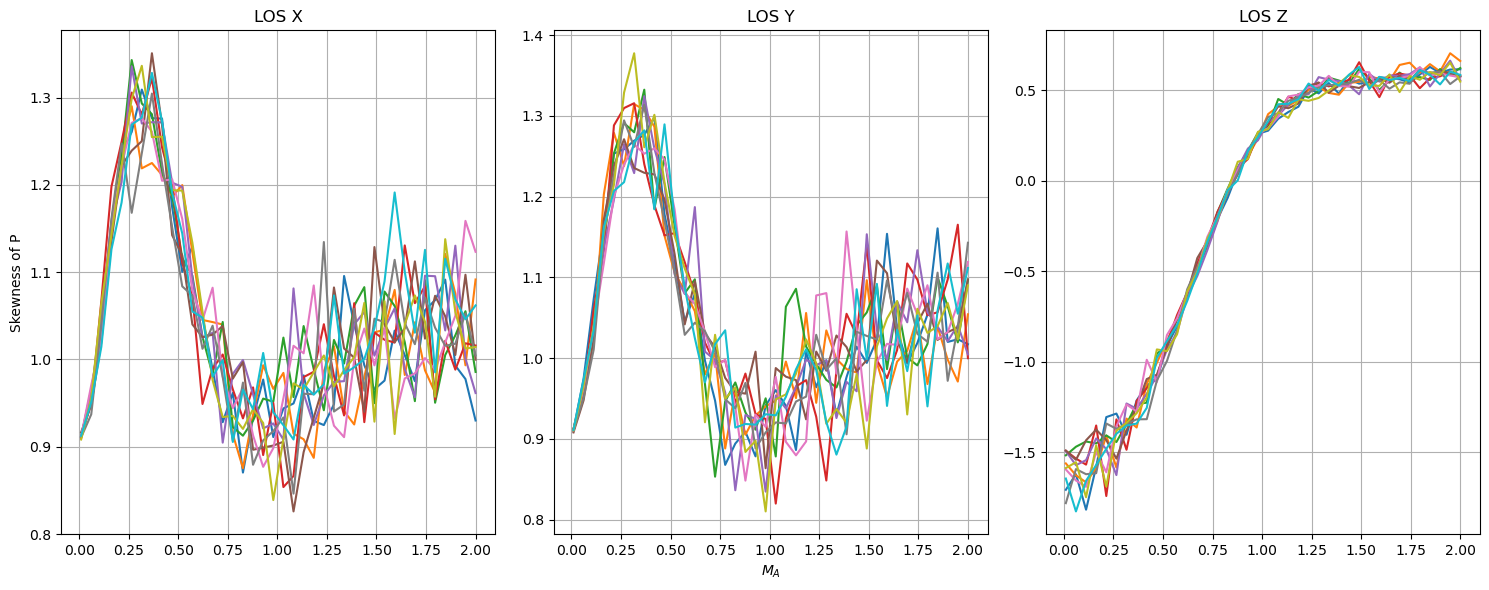

In [132]:
n = 10
fig, axes = plt.subplots(1,3,figsize=(15,6))
mach_vals = np.linspace(0.01,2,40)
gsize = 64

for nax in range(3):
    for i in range(n):
        skews = []
        for imach in mach_vals:
            P,PHI,COS = helical_field_depol_test(M_A=imach, alpha=np.pi/6, iaxis=nax, g_size=gsize, plotting=False)
            skews.append(skew(P.flatten(), bias=False))
        axes[nax].plot(mach_vals, skews, linestyle='-')

axes[1].set_xlabel(r"$M_A$")
axes[0].set_ylabel("Skewness of P")

axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')

axes[0].grid()
axes[1].grid()
axes[2].grid()
plt.tight_layout()
plt.show()


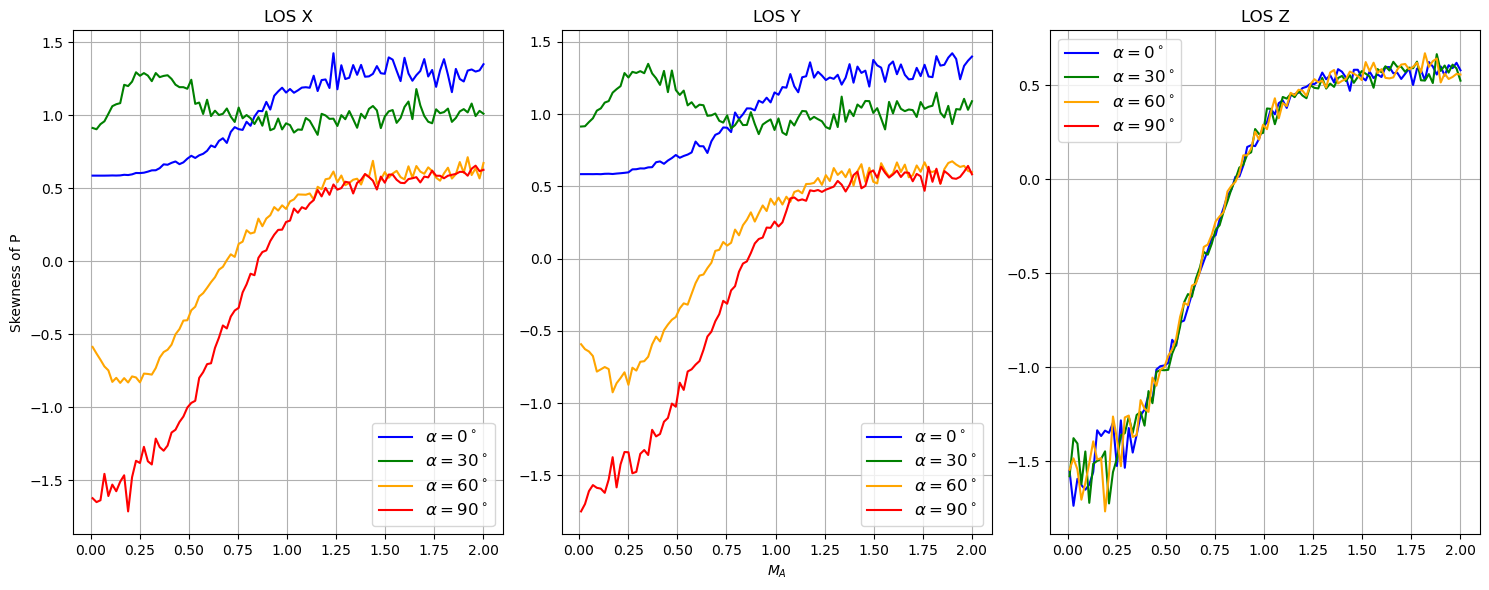

In [139]:
fig, axes = plt.subplots(1,3,figsize=(15,6))
mach_vals = np.linspace(0.01,2,100)
alphas = [0,np.pi/6, np.pi/3, np.pi/2]
colors = ['blue', 'green', 'orange','red']
gsize = 64

for nax in range(3):
    for ialpha in alphas:
        skews = []
        for imach in mach_vals:
            P,PHI,COS = helical_field_depol_test(M_A=imach, alpha=ialpha, iaxis=nax, g_size=gsize, plotting=False)
            skews.append(skew(P.flatten(), bias=False))
        axes[nax].plot(mach_vals, skews, linestyle='-', color=colors[alphas.index(ialpha)], label=r'$\alpha={:.0f}^\circ$'.format(ialpha*180/np.pi))
    axes[nax].legend(fontsize=12)
    
axes[1].set_xlabel(r"$M_A$")
axes[0].set_ylabel("Skewness of P")

axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')

axes[0].grid()
axes[1].grid()
axes[2].grid()
plt.tight_layout()
plt.show()


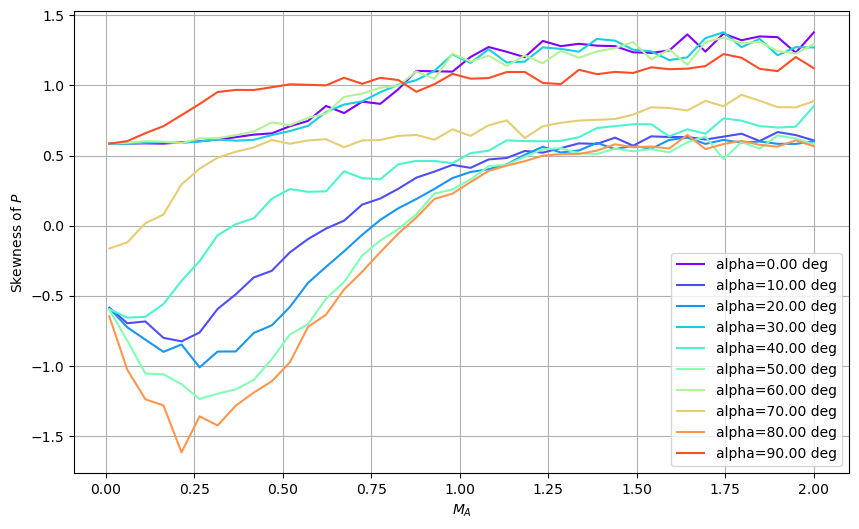

In [137]:
plt.figure(figsize=(10, 6))


n = 1
nalpha = 10
alpha_range = np.linspace(0, np.pi/2, nalpha)
color = plt.cm.rainbow(np.linspace(0,1,nalpha+1))

for ialpha in range(nalpha):
    for i in range(n):
        skews = []
        mach_vals = np.linspace(0.01,2,40)
        # mach_vals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.5,4,4.5,5]
        for imach in mach_vals:
            P,PHI,COS = helical_field_depol_test(M_A=imach, alpha=ialpha, iaxis=1, g_size=gsize, plotting=False)
            skews.append(skew(P.flatten(), bias=False))

        plt.plot(mach_vals, skews, linestyle='-', label ='alpha={:.2f} deg'.format(alpha_range[ialpha]*180/np.pi), color=color[ialpha])
    
plt.xlabel(r"$M_A$")
plt.ylabel("Skewness of $P$")
plt.grid(True)
plt.legend()
plt.show()